# Resultados de Negocio: Pronóstico de Ventas Retail

## Resumen Ejecutivo

- Este proyecto pronostica las **ventas diarias por tienda y categoría de producto** en una red de tiendas de retail en México.
- El modelo de pronóstico LightGBM se compara contra una **línea base semanal** (mismo día de la semana anterior) para verificar si agrega valor más allá de una regla operativa simple.
- El modelo **reduce el error de pronóstico** versus la línea base semanal en los segmentos principales evaluados, incluyendo categorías de producto, formatos de tienda y regiones.
- El análisis identifica **categorías, formatos, regiones y combinaciones tienda-categoría** donde el modelo aporta más valor, así como segmentos donde la incertidumbre del pronóstico sigue siendo mayor.
- El conjunto de datos no incluye inventario, desabasto, precio, margen ni datos de costos operativos. Este notebook reporta la **reducción de error de pronóstico**, que puede servir como proxy del valor potencial en planeación de demanda — pero **no es una estimación directa de ahorros financieros, utilidad o reducción de inventario**.

## Cómo Leer Este Análisis

- La **línea base semanal** es una regla operativa simple: pronosticar las ventas de esta semana para una tienda-categoría como iguales a las ventas de la misma tienda-categoría el mismo día de la semana anterior.
- El modelo se considera útil solo si **mejora esta regla simple**.
- Todas las comparaciones en este notebook se basan en la **reducción de error de pronóstico sobre `amount_total`** (monto diario de ventas registrado en amount_total) durante el período de prueba: 1 de enero – 29 de febrero de 2024.
- Un menor error de pronóstico puede apoyar una mejor planeación de demanda y priorización, pero **no es una estimación directa de ahorros financieros**.

In [1]:
import json
import warnings
from pathlib import Path

from IPython.display import Markdown, display

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Paleta corporativa
C_BASELINE = "#6B7280"  # gris  — línea base
C_MODEL    = "#1D4ED8"  # azul  — LightGBM
C_ACCENT   = "#F59E0B"  # naranja — ventas reales

# Resolve project root (directory containing pyproject.toml)
def _find_project_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / "pyproject.toml").exists():
            return parent
    return start

_nb_dir = Path.cwd()
PROJECT_ROOT = _find_project_root(_nb_dir)
DATA_DIR = PROJECT_ROOT / "data"

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Directorio de datos:     {DATA_DIR}")

Raíz del proyecto: /Users/gamaliel.torres/Proyectos/reto_tecnico_WM/retowm
Directorio de datos:     /Users/gamaliel.torres/Proyectos/reto_tecnico_WM/retowm/data


In [2]:
def fmt_amount(v):
    """Format as currency with thousands separator."""
    return f"{v:,.2f}"

def fmt_pct(v):
    """Format as percentage with 2 decimals."""
    return f"{v * 100:.2f}%"

def safe_div(num, den):
    """Division returning 0.0 if denominator is zero."""
    return float(num / den) if den != 0 else 0.0

In [3]:
# --- File paths ---
PATHS = {
    "model_comparison": DATA_DIR / "08_reporting" / "model_comparison.csv",
    "model_metrics":    DATA_DIR / "08_reporting" / "model_metrics.json",
    "segment_metrics":  DATA_DIR / "08_reporting" / "segment_metrics.csv",
    "feature_importance": DATA_DIR / "08_reporting" / "feature_importance.csv",
    "test_predictions": DATA_DIR / "07_model_output" / "test_predictions.parquet",
}

for name, path in PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")

model_comparison  = pd.read_csv(PATHS["model_comparison"])
segment_metrics   = pd.read_csv(PATHS["segment_metrics"])
feature_importance = pd.read_csv(PATHS["feature_importance"])
test_predictions  = pd.read_parquet(PATHS["test_predictions"])

with open(PATHS["model_metrics"]) as f:
    model_metrics = json.load(f)

# --- Column validation ---
_required = {
    "model_comparison":   ["model", "mae", "rmse", "smape", "relative_mae"],
    "segment_metrics":    ["segment_column", "segment_value", "model", "n_rows", "mae", "rmse", "smape", "relative_mae"],
    "test_predictions":   ["date", "store_id", "category", "y_true",
                           "baseline_lag_7_pred", "lightgbm_pred",
                           "baseline_lag_7_abs_error", "lightgbm_abs_error"],
    "feature_importance": ["importance_level", "feature", "original_feature",
                           "importance_type", "importance", "importance_pct", "rank"],
}

_frames = {
    "model_comparison": model_comparison,
    "segment_metrics": segment_metrics,
    "test_predictions": test_predictions,
    "feature_importance": feature_importance,
}

for name, required_cols in _required.items():
    missing = [c for c in required_cols if c not in _frames[name].columns]
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")

print("Archivos cargados y validados.")
print(f"  model_comparison:   {model_comparison.shape[0]} filas")
print(f"  segment_metrics:    {segment_metrics.shape[0]} filas")
print(f"  test_predictions:   {test_predictions.shape[0]:,} filas — {test_predictions['date'].min()} a {test_predictions['date'].max()}")
print(f"  feature_importance: {feature_importance.shape[0]} filas")

Archivos cargados y validados.
  model_comparison:   2 filas
  segment_metrics:    44 filas
  test_predictions:   28,782 filas — 2024-01-01 a 2024-02-29
  feature_importance: 358 filas


---
## 1. Problema de Negocio y Contexto de Decisión

Las operaciones de retail requieren anticipar **cuánto de cada categoría de producto se venderá en cada tienda, cada día**. Sin una estimación confiable, la planeación de demanda y la priorización operativa se apoyan en reglas simples o criterio manual.

Un mejor pronóstico puede apoyar procesos de planeación de demanda y priorización operativa. Este dataset no permite cuantificar directamente inventario, desabasto, desperdicio, capital de trabajo, margen, utilidad o ventas perdidas.

Este proyecto construye un modelo de pronóstico que predice `amount_total` (monto diario de ventas registrado en amount_total) al nivel de **fecha × tienda × categoría**. El modelo se evalúa contra una **línea base semanal** — si no mejora esta regla simple, no aporta valor práctico.

---
## 2. Mejora del Pronóstico vs. Línea Base Semanal

> Para mantener la lectura enfocada en negocio, este notebook usa el **error absoluto promedio** como métrica principal. Métricas técnicas adicionales como RMSE, sMAPE y MAE relativo se documentan en el notebook técnico.

,Error absoluto promedio de pronóstico,Reducción de error vs. línea base,Reducción de error %
Enfoque,,,
Línea base semanal (lag-7),"56,928.87",—,—
Pronóstico LightGBM,"49,426.42","7,502.45",13.18%


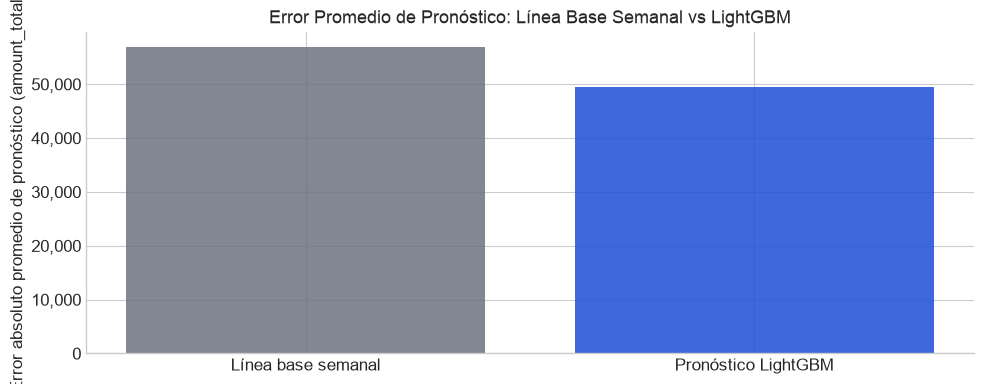


El modelo reduce el error absoluto promedio de pronóstico aproximadamente en 13.18% versus la línea base semanal.
La reducción de error promedio por tienda-categoría-día es aproximadamente 7,502.45 unidades monetarias de amount_total.


In [4]:
baseline_row = model_comparison[model_comparison["model"] == "baseline_lag_7"].iloc[0]
model_row    = model_comparison[model_comparison["model"] == "lightgbm"].iloc[0]

baseline_mae = baseline_row["mae"]
model_mae    = model_row["mae"]
abs_reduction = baseline_mae - model_mae
pct_reduction = safe_div(abs_reduction, baseline_mae)

summary_df = pd.DataFrame([
    {
        "Enfoque": "Línea base semanal (lag-7)",
        "Error absoluto promedio de pronóstico": fmt_amount(baseline_mae),
        "Reducción de error vs. línea base": "—",
        "Reducción de error %": "—",
    },
    {
        "Enfoque": "Pronóstico LightGBM",
        "Error absoluto promedio de pronóstico": fmt_amount(model_mae),
        "Reducción de error vs. línea base": fmt_amount(abs_reduction),
        "Reducción de error %": fmt_pct(pct_reduction),
    },
])

display(summary_df.set_index("Enfoque"))

# Bar chart
fig, ax = plt.subplots()
labels = ["Línea base semanal", "Pronóstico LightGBM"]
values = [baseline_mae, model_mae]
ax.bar(labels, values, color=[C_BASELINE, C_MODEL], alpha=0.85)
ax.set_title("Error Promedio de Pronóstico: Línea Base Semanal vs LightGBM")
ax.set_ylabel("Error absoluto promedio de pronóstico (amount_total)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

print(
    f"\nEl modelo reduce el error absoluto promedio de pronóstico aproximadamente en "
    f"{fmt_pct(pct_reduction)} versus la línea base semanal.\n"
    f"La reducción de error promedio por tienda-categoría-día es aproximadamente "
    f"{fmt_amount(abs_reduction)} unidades monetarias de amount_total."
)

---
## 3. Proxy de Impacto de Negocio

La tabla a continuación cuantifica la reducción total del error de pronóstico en todas las combinaciones tienda-categoría-día evaluadas en el período de prueba.

> **Nota:** La reducción del error de pronóstico se calcula sobre `amount_total`. No representa utilidad, margen, ahorro, reducción de inventario ni ventas recuperadas.

In [5]:
n_rows = len(test_predictions)
avg_base_err  = test_predictions["baseline_lag_7_abs_error"].mean()
avg_model_err = test_predictions["lightgbm_abs_error"].mean()
avg_reduction = avg_base_err - avg_model_err
avg_reduction_pct = safe_div(avg_reduction, avg_base_err)

total_base_err  = test_predictions["baseline_lag_7_abs_error"].sum()
total_model_err = test_predictions["lightgbm_abs_error"].sum()
total_reduction = total_base_err - total_model_err
total_reduction_pct = safe_div(total_reduction, total_base_err)

kpi_df = pd.DataFrame([
    {"Métrica": "Registros evaluados",                                         "Valor": f"{n_rows:,}"},
    {"Métrica": "Reducción de error promedio por tienda-categoría-día",         "Valor": f"{fmt_amount(avg_reduction)} unidades monetarias de amount_total"},
    {"Métrica": "Reducción de error promedio %",                                "Valor": fmt_pct(avg_reduction_pct)},
    {"Métrica": "Error de pronóstico (línea base) acumulado",                   "Valor": f"{fmt_amount(total_base_err)} unidades monetarias de amount_total"},
    {"Métrica": "Error de pronóstico (modelo) acumulado",                       "Valor": f"{fmt_amount(total_model_err)} unidades monetarias de amount_total"},
    {"Métrica": "Reducción de error de pronóstico acumulada",                   "Valor": f"{fmt_amount(total_reduction)} unidades monetarias de amount_total"},
    {"Métrica": "Reducción de error de pronóstico acumulada %",                 "Valor": fmt_pct(total_reduction_pct)},
])

display(kpi_df.set_index("Métrica"))

,Valor
Métrica,
Registros evaluados,"28,782"
Reducción de error promedio por tienda-categoría-día,"7,502.45 unidades monetarias de amount_total"
Reducción de error promedio %,13.18%
Error de pronóstico (línea base) acumulado,"1,638,526,693.45 unidades monetarias de amount..."
Error de pronóstico (modelo) acumulado,"1,422,591,184.44 unidades monetarias de amount..."
Reducción de error de pronóstico acumulada,"215,935,509.01 unidades monetarias de amount_t..."
Reducción de error de pronóstico acumulada %,13.18%


---
## 4. Dónde el Modelo Aporta Más Valor

Las tablas a continuación muestran la reducción de error de pronóstico desglosada por **categoría de producto**, **formato de tienda** y **región**.

Los segmentos con mayor mejora indican dónde el modelo LightGBM agrega más valor sobre la regla semanal. Los segmentos con menor mejora o mejora negativa indican dónde la incertidumbre del pronóstico sigue siendo mayor y donde datos adicionales o refinamientos de modelado pueden ser más valiosos.

### Categorías principales

,Segmento,Valor,Registros,Error de pronóstico (línea base),Error de pronóstico (modelo),Reducción de error,Reducción de error %
0,category,Abarrotes,4797,"87,147.17","72,471.55","14,675.62",16.84%
1,category,Hogar,4797,"58,228.20","50,034.70","8,193.50",14.07%
2,category,Electronica,4797,"61,028.43","53,322.12","7,706.31",12.63%
3,category,Ropa,4797,"54,681.82","47,787.34","6,894.48",12.61%
4,category,Cuidado_Personal,4797,"36,587.28","32,817.71","3,769.57",10.30%
5,category,Bebidas,4797,"43,900.31","40,125.09","3,775.22",8.60%


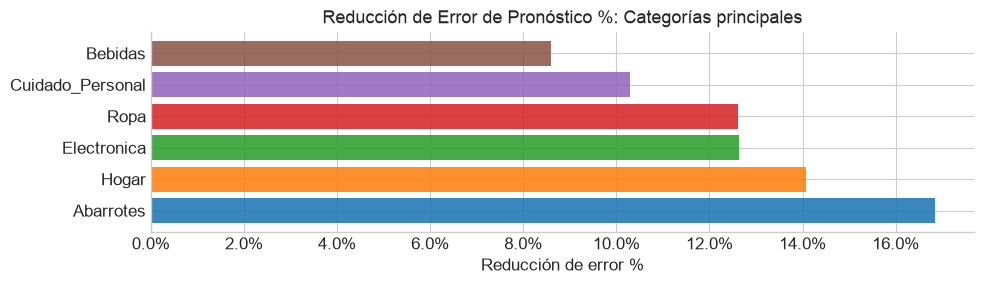

### Formatos de tienda

,Segmento,Valor,Registros,Error de pronóstico (línea base),Error de pronóstico (modelo),Reducción de error,Reducción de error %
0,store_format,Bodega,12582,"55,452.85","46,871.56","8,581.29",15.47%
1,store_format,Supercenter,7200,"97,479.73","84,623.95","12,855.78",13.19%
2,store_format,Express,9000,"26,551.65","24,840.09","1,711.56",6.45%


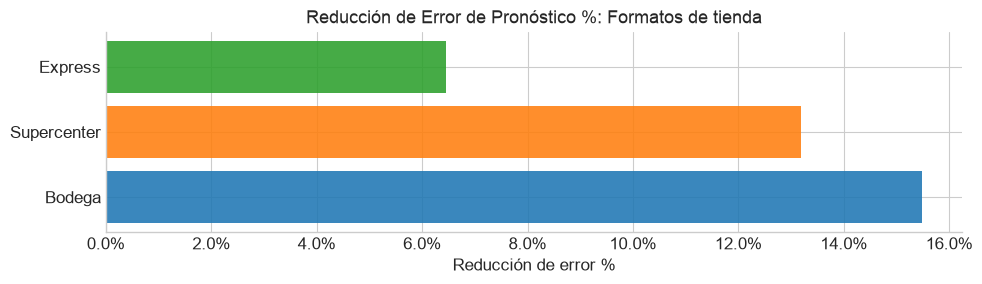

### Regiones

,Segmento,Valor,Registros,Error de pronóstico (línea base),Error de pronóstico (modelo),Reducción de error,Reducción de error %
0,region,Sur,4680,"61,666.38","53,155.51","8,510.87",13.80%
1,region,Centro,4320,"57,587.63","49,775.91","7,811.72",13.56%
2,region,Occidente,7200,"58,001.02","50,258.14","7,742.88",13.35%
3,region,Norte,6102,"57,118.17","49,767.96","7,350.21",12.87%
4,region,Oriente,6480,"51,698.61","45,254.43","6,444.18",12.46%


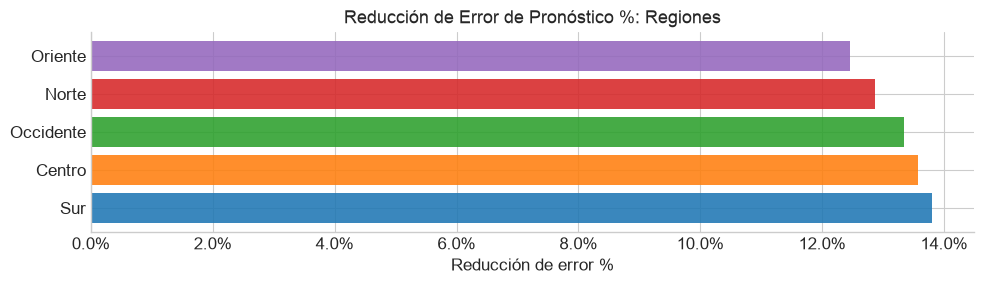

In [6]:
def _build_segment_comparison(sm, seg_col):
    """Build baseline vs. lightgbm MAE comparison for a given segment column."""
    sub = sm[sm["segment_column"] == seg_col].copy()
    baseline_sub = sub[sub["model"] == "baseline_lag_7"][["segment_value", "n_rows", "mae"]].rename(
        columns={"mae": "baseline_mae"}
    )
    lgbm_sub = sub[sub["model"] == "lightgbm"][["segment_value", "mae"]].rename(
        columns={"mae": "lightgbm_mae"}
    )
    merged = baseline_sub.merge(lgbm_sub, on="segment_value", how="inner")
    merged["segment_column"] = seg_col
    merged["error_reduction"] = merged["baseline_mae"] - merged["lightgbm_mae"]
    merged["error_reduction_pct"] = merged.apply(
        lambda r: safe_div(r["error_reduction"], r["baseline_mae"]), axis=1
    )
    merged = merged[
        ["segment_column", "segment_value", "n_rows", "baseline_mae", "lightgbm_mae",
         "error_reduction", "error_reduction_pct"]
    ].sort_values("error_reduction_pct", ascending=False).reset_index(drop=True)
    return merged


def _show_segment_table(df):
    """Display a segment comparison DataFrame with business-facing column names."""
    display_df = df.copy()
    display_df["baseline_mae"] = display_df["baseline_mae"].apply(fmt_amount)
    display_df["lightgbm_mae"] = display_df["lightgbm_mae"].apply(fmt_amount)
    display_df["error_reduction"] = display_df["error_reduction"].apply(fmt_amount)
    display_df["error_reduction_pct"] = display_df["error_reduction_pct"].apply(fmt_pct)
    display_df = display_df.rename(columns={
        "segment_column": "Segmento",
        "segment_value": "Valor",
        "n_rows": "Registros",
        "baseline_mae": "Error de pronóstico (línea base)",
        "lightgbm_mae": "Error de pronóstico (modelo)",
        "error_reduction": "Reducción de error",
        "error_reduction_pct": "Reducción de error %",
    })
    display(display_df.reset_index(drop=True))


segments_to_show = [
    ("category", "Categorías principales"),
    ("store_format", "Formatos de tienda"),
    ("region", "Regiones"),
]

for seg_col, label in segments_to_show:
    display(Markdown(f"### {label}"))
    comp = _build_segment_comparison(segment_metrics, seg_col)
    if seg_col == "category":
        _show_segment_table(comp.head(6))
    else:
        _show_segment_table(comp)

    fig, ax = plt.subplots(figsize=(10, max(3, len(comp) * 0.5)))
    bar_colors = [plt.colormaps["tab10"](i % 10) for i in range(len(comp))]
    ax.barh(comp["segment_value"], comp["error_reduction_pct"], color=bar_colors, alpha=0.88)
    ax.set_title(f"Reducción de Error de Pronóstico %: {label}")
    ax.set_xlabel("Reducción de error %")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x * 100:.1f}%"))
    plt.tight_layout()
    plt.show()

---
## 5. Dónde la Incertidumbre es Mayor

Dos vistas del desempeño al nivel individual de **tienda × categoría**:

- **Mayor incertidumbre restante**: donde el modelo aún produce los errores absolutos más grandes — estas combinaciones pueden beneficiarse más de datos adicionales, información más rica o modelado específico por categoría.
- **Mayor mejora vs. línea base semanal**: donde el modelo provee el mayor incremento sobre la regla simple.

In [7]:
store_cat = (
    test_predictions
    .groupby(["store_id", "category"])
    .agg(
        actual_sales=("y_true", "sum"),
        baseline_forecast=("baseline_lag_7_pred", "sum"),
        model_forecast=("lightgbm_pred", "sum"),
        baseline_abs_error=("baseline_lag_7_abs_error", "sum"),
        model_abs_error=("lightgbm_abs_error", "sum"),
    )
    .reset_index()
)

store_cat["error_reduction"] = store_cat["baseline_abs_error"] - store_cat["model_abs_error"]
store_cat["error_reduction_pct"] = store_cat.apply(
    lambda r: safe_div(r["error_reduction"], r["baseline_abs_error"]), axis=1
)
store_cat["model_relative_error"] = store_cat.apply(
    lambda r: safe_div(r["model_abs_error"], r["actual_sales"]), axis=1
)

# Tabla A: Top 15 por model_abs_error descendente
display(Markdown("### Tabla A: Combinaciones Tienda-Categoría con Mayor Incertidumbre de Pronóstico Restante"))
top_uncertainty = store_cat.sort_values("model_abs_error", ascending=False).head(15).copy()
table_a = top_uncertainty[["store_id", "category", "actual_sales", "model_forecast",
                            "model_abs_error", "model_relative_error"]].copy()
table_a["actual_sales"] = table_a["actual_sales"].apply(fmt_amount)
table_a["model_forecast"] = table_a["model_forecast"].apply(fmt_amount)
table_a["model_abs_error"] = table_a["model_abs_error"].apply(fmt_amount)
table_a["model_relative_error"] = table_a["model_relative_error"].apply(fmt_pct)
table_a = table_a.rename(columns={
    "store_id": "Tienda",
    "category": "Categoría",
    "actual_sales": "Ventas reales",
    "model_forecast": "Pronóstico LightGBM",
    "model_abs_error": "Error absoluto LightGBM",
    "model_relative_error": "Error relativo vs ventas reales",
})
display(table_a.reset_index(drop=True))

# Tabla B: Top 15 por error_reduction descendente
display(Markdown("### Tabla B: Combinaciones Tienda-Categoría con Mayor Mejora en el Error de Pronóstico"))
top_improvement = store_cat.sort_values("error_reduction", ascending=False).head(15).copy()
table_b = top_improvement[["store_id", "category", "baseline_abs_error",
                            "model_abs_error", "error_reduction", "error_reduction_pct"]].copy()
table_b["baseline_abs_error"] = table_b["baseline_abs_error"].apply(fmt_amount)
table_b["model_abs_error"] = table_b["model_abs_error"].apply(fmt_amount)
table_b["error_reduction"] = table_b["error_reduction"].apply(fmt_amount)
table_b["error_reduction_pct"] = table_b["error_reduction_pct"].apply(fmt_pct)
table_b = table_b.rename(columns={
    "store_id": "Tienda",
    "category": "Categoría",
    "baseline_abs_error": "Error absoluto línea base semanal",
    "model_abs_error": "Error absoluto LightGBM",
    "error_reduction": "Reducción de error",
    "error_reduction_pct": "Reducción de error %",
})
display(table_b.reset_index(drop=True))

print(
    "\nMayor incertidumbre restante: estas combinaciones pueden beneficiarse de fuentes de datos "
    "adicionales o modelado específico."
)
print(
    "Mayor mejora vs. línea base semanal: estas son las combinaciones donde el modelo LightGBM provee el "
    "mayor incremento sobre la regla semanal."
)

### Tabla A: Combinaciones Tienda-Categoría con Mayor Incertidumbre de Pronóstico Restante

,Tienda,Categoría,Ventas reales,Pronóstico LightGBM,Error absoluto LightGBM,Error relativo vs ventas reales
0,STR_017,Abarrotes,"33,967,444.56","40,705,676.97","10,257,767.68",30.20%
1,STR_001,Abarrotes,"32,641,247.76","39,986,544.58","10,241,971.39",31.38%
2,STR_017,Hogar,"22,938,389.03","28,346,022.19","8,707,690.74",37.96%
3,STR_007,Abarrotes,"25,291,315.11","31,341,871.71","8,687,783.13",34.35%
4,STR_015,Abarrotes,"23,331,553.16","29,850,763.55","8,670,510.16",37.16%
5,STR_011,Abarrotes,"28,721,352.05","34,291,381.98","8,608,022.85",29.97%
6,STR_008,Abarrotes,"25,136,168.54","31,666,183.38","8,491,316.42",33.78%
7,STR_017,Electronica,"25,192,613.18","30,953,045.70","8,484,332.83",33.68%
8,STR_002,Abarrotes,"21,000,359.72","27,075,923.29","8,226,146.01",39.17%
9,STR_018,Abarrotes,"21,131,005.95","27,400,187.69","8,129,579.16",38.47%


### Tabla B: Combinaciones Tienda-Categoría con Mayor Mejora en el Error de Pronóstico

,Tienda,Categoría,Error absoluto línea base semanal,Error absoluto LightGBM,Reducción de error,Reducción de error %
0,STR_001,Abarrotes,"14,491,686.74","10,241,971.39","4,249,715.35",29.33%
1,STR_017,Abarrotes,"13,849,723.30","10,257,767.68","3,591,955.62",25.94%
2,STR_007,Abarrotes,"12,189,004.55","8,687,783.13","3,501,221.42",28.72%
3,STR_001,Electronica,"10,811,949.67","8,046,856.68","2,765,092.99",25.57%
4,STR_003,Abarrotes,"9,610,682.49","6,859,466.01","2,751,216.48",28.63%
5,STR_011,Abarrotes,"11,271,345.56","8,608,022.85","2,663,322.71",23.63%
6,STR_014,Abarrotes,"10,284,860.63","8,044,232.73","2,240,627.90",21.79%
7,STR_018,Abarrotes,"10,228,269.88","8,129,579.16","2,098,690.72",20.52%
8,STR_008,Abarrotes,"10,468,635.07","8,491,316.42","1,977,318.65",18.89%
9,STR_014,Hogar,"8,002,709.22","6,199,391.21","1,803,318.01",22.53%



Mayor incertidumbre restante: estas combinaciones pueden beneficiarse de fuentes de datos adicionales o modelado específico.
Mayor mejora vs. línea base semanal: estas son las combinaciones donde el modelo LightGBM provee el mayor incremento sobre la regla semanal.


---
## 6. Análisis de Calendario y Eventos

El modelo se evalúa por separado para condiciones de calendario operativamente relevantes: **fines de semana**, **días de quincena** y la **temporada navideña** (finales de diciembre y principios de enero).

In [8]:
calendar_segments = ["is_weekend", "is_payday", "is_navidad_season"]

for seg_col in calendar_segments:
    display(Markdown(f"### {seg_col}"))
    comp = _build_segment_comparison(segment_metrics, seg_col)
    if comp.empty:
        print(f"  No se encontraron datos para el segmento: {seg_col}")
        continue
    display_df = comp.copy()
    display_df["baseline_mae"] = display_df["baseline_mae"].apply(fmt_amount)
    display_df["lightgbm_mae"] = display_df["lightgbm_mae"].apply(fmt_amount)
    display_df["error_reduction"] = display_df["error_reduction"].apply(fmt_amount)
    display_df["error_reduction_pct"] = display_df["error_reduction_pct"].apply(fmt_pct)
    display_df = display_df.rename(columns={
        "segment_column": "Condición",
        "segment_value": "Valor",
        "n_rows": "Registros",
        "baseline_mae": "Error de pronóstico (línea base)",
        "lightgbm_mae": "Error de pronóstico (modelo)",
        "error_reduction": "Reducción de error",
        "error_reduction_pct": "Reducción de error %",
    })
    display(display_df.reset_index(drop=True))

# Caveats for missing events
buen_fin_sub = segment_metrics[segment_metrics["segment_column"] == "is_buen_fin"]
buen_fin_has_true = (buen_fin_sub["segment_value"].astype(str) == "True").any()
if not buen_fin_has_true:
    display(Markdown(
        "**Buen Fin:** El período de prueba (enero\u2013febrero 2024) no contiene observaciones de Buen Fin. "
        "No se extraen conclusiones sobre el desempeño del modelo durante este evento."
    ))

semana_santa_sub = segment_metrics[segment_metrics["segment_column"] == "is_semana_santa"]
semana_santa_has_true = (semana_santa_sub["segment_value"].astype(str) == "True").any()
if not semana_santa_has_true:
    display(Markdown(
        "**Semana Santa:** El período de prueba (enero\u2013febrero 2024) no contiene "
        "observaciones de Semana Santa. No se extraen conclusiones sobre el desempeño del modelo durante este evento."
    ))

### is_weekend

,Condición,Valor,Registros,Error de pronóstico (línea base),Error de pronóstico (modelo),Reducción de error,Reducción de error %
0,is_weekend,True,7674,"83,696.80","63,402.46","20,294.34",24.25%
1,is_weekend,False,21108,"47,197.15","44,345.30","2,851.84",6.04%


### is_payday

,Condición,Valor,Registros,Error de pronóstico (línea base),Error de pronóstico (modelo),Reducción de error,Reducción de error %
0,is_payday,True,1920,"47,846.80","36,064.79","11,782.02",24.62%
1,is_payday,False,26862,"57,578.02","50,381.46","7,196.56",12.50%


### is_navidad_season

,Condición,Valor,Registros,Error de pronóstico (línea base),Error de pronóstico (modelo),Reducción de error,Reducción de error %
0,is_navidad_season,True,2880,"158,302.90","123,535.82","34,767.08",21.96%
1,is_navidad_season,False,25902,"45,657.26","41,186.32","4,470.94",9.79%


**Buen Fin:** El período de prueba (enero–febrero 2024) no contiene observaciones de Buen Fin. No se extraen conclusiones sobre el desempeño del modelo durante este evento.

**Semana Santa:** El período de prueba (enero–febrero 2024) no contiene observaciones de Semana Santa. No se extraen conclusiones sobre el desempeño del modelo durante este evento.

---
## 7. Vista Diaria Agregada del Pronóstico

Esta vista muestra qué tan bien el modelo rastrea las **ventas totales diarias en todas las tiendas y categorías** durante el período de prueba.

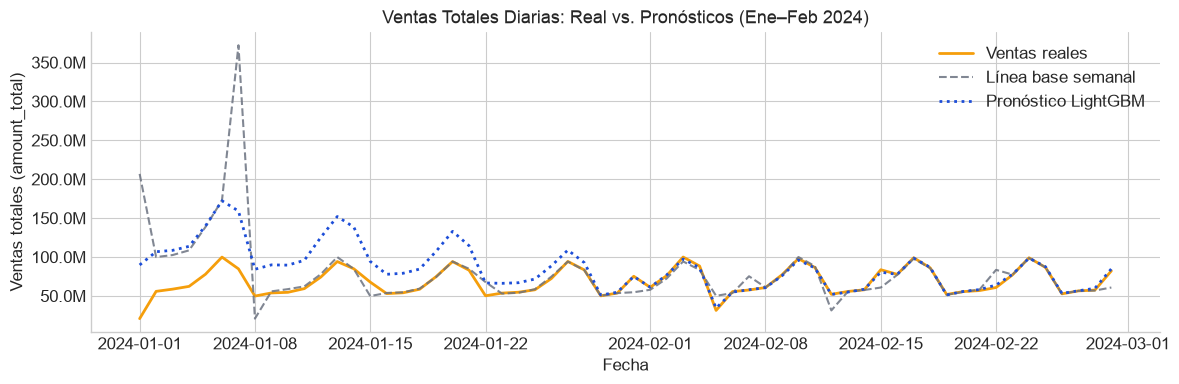

Esta vista muestra si el modelo rastrea el movimiento general de ventas diarias en el período de prueba. Los picos o caídas grandes visibles en la línea de ventas reales (p. ej., alrededor del 1 de enero) podrían estar asociados con efectos de calendario, temporada o comportamiento agregado de ventas.

In [9]:
daily = (
    test_predictions
    .groupby("date_dt")
    .agg(
        actual_sales=("y_true", "sum"),
        baseline_forecast=("baseline_lag_7_pred", "sum"),
        model_forecast=("lightgbm_pred", "sum"),
    )
    .reset_index()
    .sort_values("date_dt")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily["date_dt"], daily["actual_sales"],       label="Ventas reales",       color=C_ACCENT,   linewidth=2)
ax.plot(daily["date_dt"], daily["baseline_forecast"],  label="Línea base semanal",  color=C_BASELINE, linewidth=1.5, linestyle="--", alpha=0.85)
ax.plot(daily["date_dt"], daily["model_forecast"],     label="Pronóstico LightGBM", color=C_MODEL,    linewidth=2,   linestyle=":")
ax.set_title("Ventas Totales Diarias: Real vs. Pronósticos (Ene\u2013Feb 2024)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas totales (amount_total)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend()
plt.tight_layout()
plt.show()

display(Markdown(
    "Esta vista muestra si el modelo rastrea el movimiento general de ventas diarias en el período de prueba. "
    "Los picos o caídas grandes visibles en la línea de ventas reales (p. ej., alrededor del 1 de enero) "
    "podrían estar asociados con efectos de calendario, temporada o comportamiento agregado de ventas."
))

---
## 8. Señales Predictivas Principales

Las siguientes variables tuvieron la mayor relevancia predictiva en el modelo LightGBM (medida por ganancia de información).

> Las señales mostradas reflejan relevancia predictiva dentro del modelo. No deben interpretarse como efectos causales: una variable puede ayudar a predecir ventas sin ser necesariamente la causa directa de esas ventas.

In [10]:
fi_top = (
    feature_importance[
        (feature_importance["importance_level"] == "original_feature") &
        (feature_importance["importance_type"] == "gain")
    ]
    .sort_values("rank")
    .head(10)
    .copy()
)

fi_display = fi_top[["feature", "importance_pct"]].copy()
fi_display.columns = ["Variable", "Importancia predictiva %"]
fi_display["Importancia predictiva %"] = fi_display["Importancia predictiva %"].apply(fmt_pct)
fi_display = fi_display.reset_index(drop=True)
fi_display.index = fi_display.index + 1
display(fi_display)

display(Markdown(
    "El modelo se apoya principalmente en el historial reciente de ventas (rezagos semanales y bisemanales, "
    "promedios móviles), variables de calendario y eventos (nombre del feriado, día de la semana, semana del año, "
    "variables de calendario y eventos comerciales) y contexto de tienda y categoría. Esto es consistente con el pronóstico de demanda en retail."
))

,Variable,Importancia predictiva %
1,amount_total_lag_7,26.35%
2,amount_total_lag_14,20.99%
3,amount_total_rolling_mean_28,16.55%
4,holiday_name,12.94%
5,amount_total_rolling_mean_7,6.03%
6,amount_total_lag_28,5.51%
7,day_of_week,3.01%
8,week_of_year,2.29%
9,is_buen_fin,1.83%
10,is_payday,1.16%


El modelo se apoya principalmente en el historial reciente de ventas (rezagos semanales y bisemanales, promedios móviles), variables de calendario y eventos (nombre del feriado, día de la semana, semana del año, variables de calendario y eventos comerciales) y contexto de tienda y categoría. Esto es consistente con el pronóstico de demanda en retail.

---
## 9. Qué Habilita Este Análisis

Un pronóstico de ventas diarias funcional por tienda y categoría puede apoyar:

- **Planeación diaria de demanda** — anticipar qué tiendas y categorías necesitan atención de reabastecimiento antes del día.
- **Priorización comercial** — enfocar la revisión y las visitas de campo en combinaciones con mayor incertidumbre o mayor error absoluto de pronóstico.
- **Monitoreo de desempeño** — identificar qué categorías o formatos de tienda están operando por encima o por debajo del pronóstico, antes de los cierres de período.
- **Perspectiva por segmento** — identificar qué formatos de tienda, regiones o categorías se benefician más de un pronóstico basado en datos versus una regla simple.
- **Fundamento para casos de uso futuros** — si se dispone de datos de inventario, precio, desabasto y margen, este pronóstico puede alimentar modelos de reabastecimiento, estimación de ventas perdidas o impacto en margen.

---
## 10. Limitaciones y Próximos Pasos

**Alcance del análisis actual:**

- El conjunto de datos cubre aproximadamente **14 meses** (enero 2023 – febrero 2024).
- El período de prueba es **enero–febrero 2024 únicamente** (60 días). Una ventana de prueba más larga proporcionaría estimaciones más robustas de la generalización del modelo.
- **Buen Fin** (noviembre) y **Semana Santa** (abril) no tienen observaciones positivas en el período de prueba enero–febrero. El desempeño del modelo durante estos eventos de alto tráfico no puede evaluarse únicamente con este conjunto de datos.

**Limitaciones de datos:**

- El conjunto de datos no incluye **niveles de inventario, desabasto, precio, margen, desperdicio ni costos operativos**.
- Por esta razón, este notebook reporta la **reducción de error de pronóstico**, que es un proxy del valor operativo potencial — no una estimación directa del impacto financiero.

**Próximos pasos naturales:**

- Validar el modelo en un horizonte de prueba más largo, incluyendo Buen Fin y Semana Santa.
- Incorporar datos de inventario, precio y margen para traducir la mejora del pronóstico en estimaciones de reabastecimiento o ventas perdidas.
- Explorar modelos específicos por categoría o región para segmentos con alta incertidumbre restante.
- Implementar reentrenamiento continuo a medida que se disponga de nuevos datos de transacciones.